Best Cp Model Coefficients (k=3):
const    1.128035
X        1.906466
X2       3.024678
X3       4.078845
dtype: float64


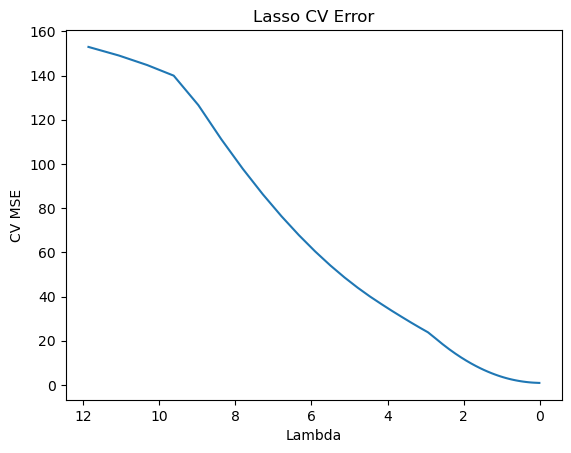

Lasso Coefficients:
X       1.690317
X2      2.795793
X3     10.431095
X4      0.468986
X5      0.000000
X6      0.133609
X7      0.000000
X8      0.000000
X9      0.000000
X10     0.000000
dtype: float64
Selected Variables: ['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Sex_I', 'Sex_M']
OLS fitted with 10 predictors (incl. intercept) and 90615 rows.
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                 1.546e+04
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:01:10   Log-Likelihood:            -1.9115e+05
No. Observations:               90615   AIC:                         3.823e+05
Df Residuals:                   90605  

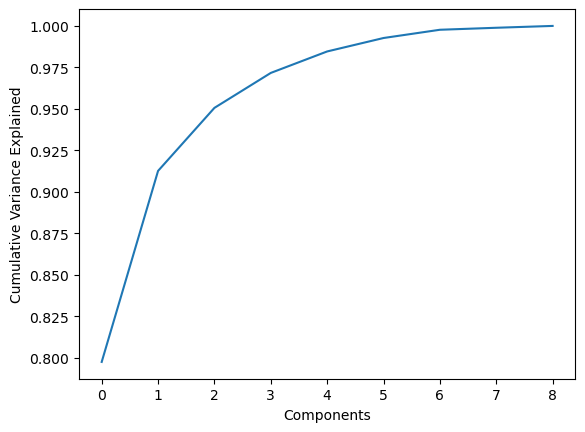

PCR R^2: 0.4296186139548074
Saved submission.csv


In [5]:
# Assignment 3 – Nonlinear Models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import itertools

np.random.seed(1)

# -------------------------
# Part 2: Simulated Data
# -------------------------

n = 100
X = np.random.normal(size=n)
eps = np.random.normal(size=n)

beta0, beta1, beta2, beta3 = 1, 2, 3, 4
Y = beta0 + beta1*X + beta2*X**2 + beta3*X**3 + eps

df = pd.DataFrame({'X':X, 'Y':Y})

# Generate polynomial terms up to X^10
for i in range(2,11):
    df[f'X{i}'] = df['X']**i

# -------------------------
# Forward Stepwise (Cp approximation)
# -------------------------

def calculate_cp(model, X, y):
    n = len(y)
    rss = np.sum((model.predict(X) - y)**2)
    d = X.shape[1]
    sigma2 = np.var(y)
    return (rss + 2*d*sigma2)/n

predictors = [f'X{i}' if i>1 else 'X' for i in range(1,11)]
best_models = {}

for k in range(1,11):
    combos = list(itertools.combinations(predictors,k))
    best_cp = np.inf
    for combo in combos:
        X_temp = sm.add_constant(df[list(combo)])
        model = sm.OLS(df['Y'], X_temp).fit()
        cp = calculate_cp(model, X_temp, df['Y'])
        if cp < best_cp:
            best_cp = cp
            best_models[k] = model

print("Best Cp Model Coefficients (k=3):")
print(best_models[3].params)

# -------------------------
# Lasso
# -------------------------

scaler = StandardScaler()
X_poly = scaler.fit_transform(df[predictors])

lasso = LassoCV(cv=5)
lasso.fit(X_poly, Y)

plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.xlabel("Lambda")
plt.ylabel("CV MSE")
plt.title("Lasso CV Error")
plt.gca().invert_xaxis()
plt.show()

print("Lasso Coefficients:")
print(pd.Series(lasso.coef_, index=predictors))

# -------------------------
# Kaggle – Abalone Example
# -------------------------

train = pd.read_csv("train.csv")

# Separate target; force numeric
y = pd.to_numeric(train["Rings"], errors="raise")

# Drop target + id from predictors
X_raw = train.drop(columns=["Rings", "id"], errors="ignore")

# One-hot encode categoricals
X = pd.get_dummies(X_raw, drop_first=True)

# Force all features numeric (will error if something is still weird)
X = X.apply(pd.to_numeric, errors="raise")

# Regularized Model (scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_kaggle = LassoCV(cv=5, random_state=1)
lasso_kaggle.fit(X_scaled, y)

selected = X.columns[lasso_kaggle.coef_ != 0].tolist()
print("Selected Variables:", selected)

# If Lasso selected nothing, fallback to top 10 by absolute coef
if len(selected) == 0:
    top_idx = np.argsort(np.abs(lasso_kaggle.coef_))[-10:]
    selected = X.columns[top_idx].tolist()
    print("Lasso selected none; fallback selected:", selected)

# -------------------------
# Refit OLS
# -------------------------

# Ensure selected is a python list
selected = list(selected)

# Slice the encoded design matrix
X_sel = X.loc[:, selected].copy()

# Force numeric and clean weird values
X_sel = X_sel.apply(pd.to_numeric, errors="coerce")
X_sel = X_sel.replace([np.inf, -np.inf], np.nan)

# Drop any columns that became all-NaN
X_sel = X_sel.dropna(axis=1, how="all")

# Drop rows with NaN in X_sel and align y
mask = ~X_sel.isna().any(axis=1)
X_sel = X_sel.loc[mask]
y_ols = pd.to_numeric(y, errors="coerce").loc[mask]

# Add constant and convert to pure float arrays for statsmodels
X_selected = sm.add_constant(X_sel, has_constant="add")
ols_model = sm.OLS(y_ols.values.astype(float), X_selected.values.astype(float)).fit()

print("OLS fitted with", X_selected.shape[1], "predictors (incl. intercept) and", X_selected.shape[0], "rows.")
print(ols_model.summary())

# PCR
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Variance Explained")
plt.show()

n_comp = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
X_reduced = X_pca[:, :n_comp]

regr = LinearRegression()
regr.fit(X_reduced, y)
print("PCR R^2:", regr.score(X_reduced, y))

# Create Kaggle submission file
test = pd.read_csv("test.csv")

test_raw = test.drop(columns=["id"], errors="ignore")
test_X = pd.get_dummies(test_raw, drop_first=True)

# Align columns to training design matrix
test_X = test_X.reindex(columns=X.columns, fill_value=0)

test_scaled = scaler.transform(test_X)
predictions = lasso_kaggle.predict(test_scaled)

submission = pd.DataFrame({
    "id": test["id"],
    "Rings": predictions
})

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")